In [1]:
import sys
import numpy as np

print(sys.executable)
print(np.__version__)

c:\Users\szonj\anaconda3\python.exe
2.0.2


In [ ]:
import sys
sys.path.append('./script/simulator/')

from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import ast
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import defaultdict
from joblib import Parallel, delayed


import os


plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "Arial",
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 18,
})
mpl.rcParams['animation.embed_limit'] = 2000  

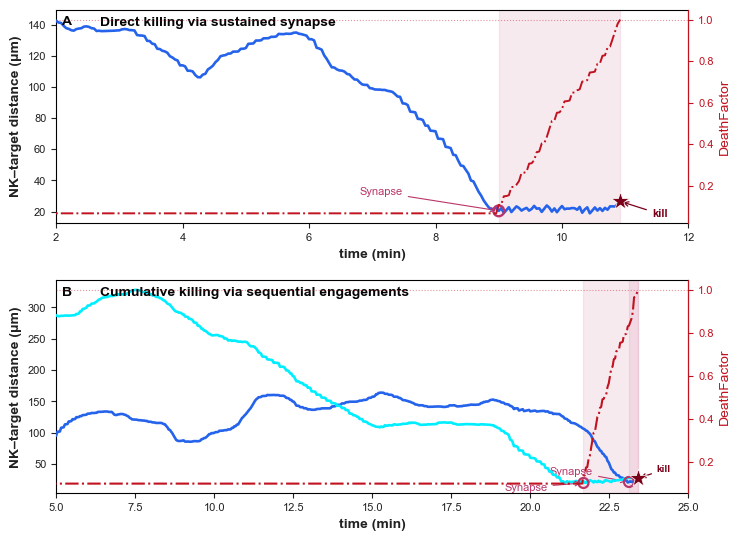

In [ ]:
"""
NK trajectory schematic figure
==============================

X-axis: real time (h), converted from simulation step using DT0 = 1/25, DS = 1
Y-axis: Euclidean distance between NK cell and target cell (μm)

Panel 1:
    Direct killing via sustained synapse
    - one NK
    - one target
    - one contact bout
    - one kill

Panel 2:
    Cumulative killing via sequential engagements
    - one target
    - multiple NK cells engaging sequentially
    - DeathFactor accumulates
    - target dies after cumulative interactions
"""

# ── CONFIG ─────────────────────────────────────────────────────────────────────

DATA_PATH = "C:\\Szonja\\UNI\\FYP\\MantiShrimp-main - Copy\\Output_excel\\posterextended.csv"
OUTPUT_PATH = "nk_trajectory_schematic.png"
DPI = 220

# Time conversion: DS = 1, DT0 = 1/25
DT0 = 1 / 25
DS = 1
STEP_TO_TIME = DS * DT0  # hours per step

# Panel 1: clean single-kill example
PANEL_1 = dict(
    nk_id=4,
    target_id=24,
    kill_step=273,
    title="Direct killing via sustained synapse",
)

# Panel 2: cumulative/sequential example
PANEL_2 = dict(
    target_id=34,
    nk_ids=[2, 17],
    kill_step=None, 
    title="Cumulative killing via sequential engagements",
)

C = {
    "bg": "none",
    "panel_bg": "none",
    "spine": "#000000",
    "text": "#050505",
    "dim": "#222222",

    "target": "#0F766E",
    "deathfactor": "#C1121F",
    "kill": "#7A0019",
    "contact": "#B9366AFF",
    "contact_fill": "#B9366A89",

    # NK colours for multi-NK panel
    "nk1": "#2563EB",
    "nk2": "#00EEFF",
    "nk_single": "#2563EB",
}


def parse_contacts(val):
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    if isinstance(val, str):
        s = val.strip()
        if s == "":
            return []
        try:
            return ast.literal_eval(s)
        except Exception:
            return []
    return []


def load_data(path):
    df = pd.read_csv(path)
    df["contacts_parsed"] = df["contacts"].apply(parse_contacts)
    return df


def get_cell(df, cell_type, cell_id):
    out = df[(df["cell_type"] == cell_type) & (df["cell_id"] == cell_id)].copy()
    out = out.sort_values("step").reset_index(drop=True)
    return out


def add_pair_contact_flag(nk_df, target_id):
    nk_df = nk_df.copy()
    nk_df["pair_contact"] = nk_df["contacts_parsed"].apply(
        lambda lst: target_id in lst if isinstance(lst, list) else False
    )
    return nk_df


def get_contact_bouts_from_flag(df_with_flag, flag_col="pair_contact"):
    bouts = []
    in_bout = False
    start = None

    steps = df_with_flag["step"].tolist()
    flags = df_with_flag[flag_col].tolist()

    for i, (step, flag) in enumerate(zip(steps, flags)):
        if flag and not in_bout:
            start = step
            in_bout = True
        elif not flag and in_bout:
            bouts.append((start, steps[i - 1]))
            in_bout = False

    if in_bout and len(steps) > 0:
        bouts.append((start, steps[-1]))

    return bouts


def infer_target_kill_step(target_df):
    if "alive_status" not in target_df.columns or target_df.empty:
        return None
    dead_rows = target_df[target_df["alive_status"] == False]
    if dead_rows.empty:
        return None
    return int(dead_rows["step"].min())


def restrict_to_step(df, max_step):
    if max_step is None:
        return df.copy()
    return df[df["step"] <= max_step].copy()


def euclidean_distance_df(nk_df, target_df):
    """
    Merge NK and target on step, compute Euclidean distance.
    Returns DataFrame with: step, time_h, distance
    """
    merged = pd.merge(
        nk_df[["step", "x", "y"]],
        target_df[["step", "x", "y"]],
        on="step",
        suffixes=("_nk", "_t")
    )
    merged["distance"] = np.sqrt(
        (merged["x_nk"] - merged["x_t"])**2 + (merged["y_nk"] - merged["y_t"])**2
    )
    merged["time_h"] = merged["step"] * STEP_TO_TIME
    return merged


def plot_single_pair_panel(ax, df, nk_id, target_id, kill_step, title):
    nk_df = get_cell(df, "killer", nk_id)
    target_df = get_cell(df, "target", target_id)

    if nk_df.empty or target_df.empty:
        ax.text(0.5, 0.5, "Missing data for Panel 1", transform=ax.transAxes,
                ha="center", va="center", color=C["text"])
        return

    nk_df = add_pair_contact_flag(nk_df, target_id)
    contact_bouts = get_contact_bouts_from_flag(nk_df, "pair_contact")

    if kill_step is None:
        kill_step = infer_target_kill_step(target_df)

    dist_df = euclidean_distance_df(nk_df, target_df)

    # Only plot while target is alive
    t_alive_steps = set(target_df[target_df["alive_status"] == True]["step"].tolist())
    dist_alive = dist_df[dist_df["step"].isin(t_alive_steps)]
    if dist_alive.empty:
        dist_alive = restrict_to_step(dist_df, kill_step)

    ax.set_facecolor(C["panel_bg"])
    for spine in ax.spines.values():
        spine.set_color(C["spine"])

    ax.set_xlim(2, 12)   

    # NK–target distance trajectory
    ax.plot(
        dist_alive["time_h"], dist_alive["distance"],
        color=C["nk_single"], lw=1.9, zorder=3
    )

    # pair-specific contact bouts
    for i, (b_start, b_end) in enumerate(contact_bouts):
        t_start = b_start * STEP_TO_TIME
        t_end = b_end * STEP_TO_TIME
        ax.axvspan(t_start, t_end, color=C["contact_fill"], alpha=0.10, zorder=1)

        row = dist_df[dist_df["step"] == b_start]
        if not row.empty:
            tv = row["time_h"].values[0]
            dv = row["distance"].values[0]
            ax.scatter(
                [tv], [dv],
                s=60, facecolors="none", edgecolors=C["contact"],
                linewidths=1.7, zorder=5
            )
            if i == 0:
                ax.annotate(
                    "Synapse",
                    xy=(tv, dv),
                    xytext=(tv - 2.2, dv + 10),
                    fontsize=8, color=C["contact"],
                    arrowprops=dict(arrowstyle="->", lw=0.8, color=C["contact"])
                )

    # kill marker
    if kill_step is not None:
        row = dist_df[dist_df["step"] == kill_step]
        if not row.empty:
            tv = row["time_h"].values[0]
            dv = row["distance"].values[0]
            ax.scatter(
                [tv], [dv],
                s=180, marker="*", color=C["kill"],
                edgecolors="white", linewidths=0.5, zorder=6
            )
            ax.annotate(
                "kill",
                xy=(tv, dv),
                xytext=(tv + 0.5, dv - 10),
                fontsize=8, color=C["kill"], fontweight="bold",
                arrowprops=dict(arrowstyle="->", lw=0.9, color=C["kill"])
            )

    # death factor on twin axis
    ax2 = ax.twinx()
    df_curve = restrict_to_step(target_df[["step", "Death_Factor"]].dropna(), kill_step).copy()
    df_curve["time_h"] = df_curve["step"] * STEP_TO_TIME
    ax2.plot(
        df_curve["time_h"], df_curve["Death_Factor"],
        color=C["deathfactor"], lw=1.4, ls="-.", zorder=3
    )
    ax2.axhline(1.0, color=C["deathfactor"], lw=0.8, alpha=0.45, ls=":")

    ax2.set_ylabel("DeathFactor", color=C["deathfactor"], fontsize=10)
    ax2.tick_params(axis="y", colors=C["deathfactor"], labelsize=8)
    ax2.spines["right"].set_color(C["deathfactor"])
    for s in ["top", "left", "bottom"]:
        ax2.spines[s].set_visible(False)

    # labels
    ax.set_xlabel("time (min)", fontsize=10, fontweight="bold", color=C["dim"])
    ax.set_ylabel("NK–target distance (μm)", fontsize=10, fontweight="bold", color=C["dim"])
    ax.tick_params(axis="both", colors=C["dim"], labelsize=8)

    ax.text(0.01, 0.97, "A", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", color=C["text"])
    ax.text(0.07, 0.97, title, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", color=C["text"])

    handles = [
        Line2D([0], [0], color=C["nk_single"], lw=1.9, label=f"NK {nk_id}–Target {target_id} distance"),
        Line2D([0], [0], color=C["deathfactor"], lw=1.4, ls="-.", label="DeathFactor"),
    ]
    #ax.legend(
     #   handles=handles,
      #  loc="upper right",
      #  fontsize=9,
      #  facecolor="white",
      #  edgecolor=C["spine"],
      #  labelcolor=C["text"]
    #)


# ── PANEL 2: TARGET-CENTRIC SEQUENTIAL ENGAGEMENTS ────────────────────────────

def plot_sequential_target_panel(ax, df, target_id, nk_ids, kill_step, title):
    target_df = get_cell(df, "target", target_id)

    if target_df.empty:
        ax.text(0.5, 0.5, "Missing target data for Panel 2", transform=ax.transAxes,
                ha="center", va="center", color=C["text"])
        return

    if kill_step is None:
        kill_step = infer_target_kill_step(target_df)

    ax.set_facecolor(C["panel_bg"])
    for spine in ax.spines.values():
        spine.set_color(C["spine"])

    nk_colours = [C["nk1"], C["nk2"]]
    legend_handles = []

    y_offsets = [12, -12, 20, -20]

    for idx, nk_id in enumerate(nk_ids):
        nk_df = get_cell(df, "killer", nk_id)
        if nk_df.empty:
            continue

        nk_df = add_pair_contact_flag(nk_df, target_id)
        bouts = get_contact_bouts_from_flag(nk_df, "pair_contact")
        nk_color = nk_colours[idx % len(nk_colours)]

        # compute distance; truncate around kill window
        if kill_step is not None:
            nk_plot = nk_df[nk_df["step"] <= kill_step + 20].copy()
            tgt_plot = target_df[target_df["step"] <= kill_step + 20].copy()
        else:
            nk_plot = nk_df.copy()
            tgt_plot = target_df.copy()

        dist_df = euclidean_distance_df(nk_plot, tgt_plot)
        t_alive_steps = set(target_df[target_df["alive_status"] == True]["step"].tolist())
        dist_alive = dist_df[dist_df["step"].isin(t_alive_steps)]
        if dist_alive.empty:
            dist_alive = dist_df

        ax.set_xlim(5, 25)    

        ax.plot(
            dist_alive["time_h"], dist_alive["distance"],
            color=nk_color, lw=1.9, zorder=3
        )

        # highlight pair-specific bouts
        for j, (b_start, b_end) in enumerate(bouts):
            t_start = b_start * STEP_TO_TIME
            t_end = b_end * STEP_TO_TIME
            ax.axvspan(t_start, t_end, color=C["contact_fill"], alpha=0.10, zorder=1)

            row = dist_df[dist_df["step"] == b_start]
            if not row.empty:
                tv = row["time_h"].values[0]
                dv = row["distance"].values[0]
                ax.scatter(
                    [tv], [dv],
                    s=52, facecolors="none", edgecolors=C["contact"],
                    linewidths=1.6, zorder=5
                )

                if j == 0:
                    yoff = y_offsets[idx % len(y_offsets)]
                    ax.annotate(
                        "Synapse",
                        xy=(tv, dv),
                        xytext=(tv - 2.5, dv + yoff),
                        fontsize=8, color=C["contact"],
                        arrowprops=dict(arrowstyle="->", lw=0.8, color=C["contact"])
                    )

        legend_handles.append(
            Line2D([0], [0], color=nk_color, lw=1.4, label=f"NK {nk_id}–Target {target_id} distance")
        )

    # kill marker (placed at the distance value of the last NK in list, at kill_step)
    if kill_step is not None:
        last_nk_df = get_cell(df, "killer", nk_ids[-1])
        if not last_nk_df.empty:
            dist_kill = euclidean_distance_df(last_nk_df, target_df)
            row = dist_kill[dist_kill["step"] == kill_step]
            if not row.empty:
                tv = row["time_h"].values[0]
                dv = row["distance"].values[0]
                ax.scatter(
                    [tv], [dv],
                    s=180, marker="*", color=C["kill"],
                    edgecolors="white", linewidths=0.5, zorder=6
                )
                ax.annotate(
                    "kill",
                    xy=(tv, dv),
                    xytext=(tv + 0.6, dv + 10),
                    fontsize=7.2, color=C["kill"], fontweight="bold",
                    arrowprops=dict(arrowstyle="->", lw=0.9, color=C["kill"])
                )

    # DeathFactor on twin axis
    ax2 = ax.twinx()
    df_curve = restrict_to_step(target_df[["step", "Death_Factor"]].dropna(), kill_step).copy()
    df_curve["time_h"] = df_curve["step"] * STEP_TO_TIME
    ax2.plot(
        df_curve["time_h"], df_curve["Death_Factor"],
        color=C["deathfactor"], lw=1.5, ls="-.", zorder=4
    )
    ax2.axhline(1.0, color=C["deathfactor"], lw=0.8, alpha=0.45, ls=":")

    ax2.set_ylabel("DeathFactor", color=C["deathfactor"], fontsize=10)
    ax2.tick_params(axis="y", colors=C["deathfactor"], labelsize=8)
    ax2.spines["right"].set_color(C["deathfactor"])
    for s in ["top", "left", "bottom"]:
        ax2.spines[s].set_visible(False)

    ax.set_xlabel("time (min)", fontsize=10, fontweight="bold", color=C["dim"])
    ax.set_ylabel("NK–target distance (μm)", fontsize=10, fontweight="bold", color=C["dim"])
    ax.tick_params(axis="both", colors=C["dim"], labelsize=8)

    ax.text(0.01, 0.97, "B", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", color=C["text"])
    ax.text(0.07, 0.97, title, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top", color=C["text"])

    legend_handles.append(
        Line2D([0], [0], color=C["deathfactor"], lw=1.5, ls="-.", label="DeathFactor"),
    )
    #ax.legend(
     #   handles=legend_handles,
      #  loc="upper right",
       # fontsize=9,
       # facecolor="white",
       # edgecolor=C["spine"],
       # labelcolor=C["text"]
    #)


# ── MAIN ───────────────────────────────────────────────────────────────────────

def main():
    df = load_data(DATA_PATH)

    fig, axes = plt.subplots(2, 1, figsize=(7.6, 5.6), facecolor=C["bg"])
    fig.patch.set_facecolor(C["bg"])

    plot_single_pair_panel(
        ax=axes[0],
        df=df,
        nk_id=PANEL_1["nk_id"],
        target_id=PANEL_1["target_id"],
        kill_step=PANEL_1["kill_step"],
        title=PANEL_1["title"],
    )

    plot_sequential_target_panel(
        ax=axes[1],
        df=df,
        target_id=PANEL_2["target_id"],
        nk_ids=PANEL_2["nk_ids"],
        kill_step=PANEL_2["kill_step"],
        title=PANEL_2["title"],
    )

    plt.tight_layout(pad=1.4)
    plt.savefig(OUTPUT_PATH, dpi=DPI, bbox_inches="tight", transparent=True)
    plt.show()


if __name__ == "__main__":
    main()
